Imports

In [3]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import time

Load Data

In [4]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_valid = pd.read_csv("../data/processed/X_valid.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_valid = pd.read_csv("../data/processed/y_valid.csv").squeeze()

Create Models

In [5]:
models = {
    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(),

    "Lasso Regression": Lasso(),

    "Random Forest": RandomForestRegressor(
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        random_state=42,
        objective="reg:squarederror"
    )
}

Evaluation Function

In [6]:
results = []

def evaluate_model(name, model):

    start = time.time()

    model.fit(X_train, y_train)

    predictions = model.predict(X_valid)

    end = time.time()

    mae = mean_absolute_error(
        y_valid,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_valid,
            predictions
        )
    )

    r2 = r2_score(
        y_valid,
        predictions
    )

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Training Time (s)": end - start
    })

    return model

Train Every Model

In [8]:
X_train.select_dtypes(include="object").columns

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')

In [9]:
# Convert categorical variables to dummy variables
X_train = pd.get_dummies(X_train)
X_valid = pd.get_dummies(X_valid)

# Ensure both datasets have the same columns
X_train, X_valid = X_train.align(
    X_valid,
    join="left",
    axis=1,
    fill_value=0
)

print(X_train.shape)
print(X_valid.shape)

(1168, 286)
(292, 286)


In [10]:
trained_models = {}

for name, model in models.items():
    trained_models[name] = evaluate_model(name, model)

In [11]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="RMSE"
)

results_df

,Model,MAE,RMSE,R2,Training Time (s)
4,Gradient Boosting,16403.442017,25801.286069,0.913210,1.520952
5,XGBoost,17493.976562,27595.964922,0.900716,1.119262
2,Lasso Regression,17865.678696,28180.806224,0.896464,0.323065
0,Linear Regression,18262.222435,29558.548723,0.886092,0.204683
1,Ridge Regression,19099.129407,29654.167261,0.885354,0.027705
3,Random Forest,17749.495171,29655.904217,0.885341,4.992633


Visualize Results

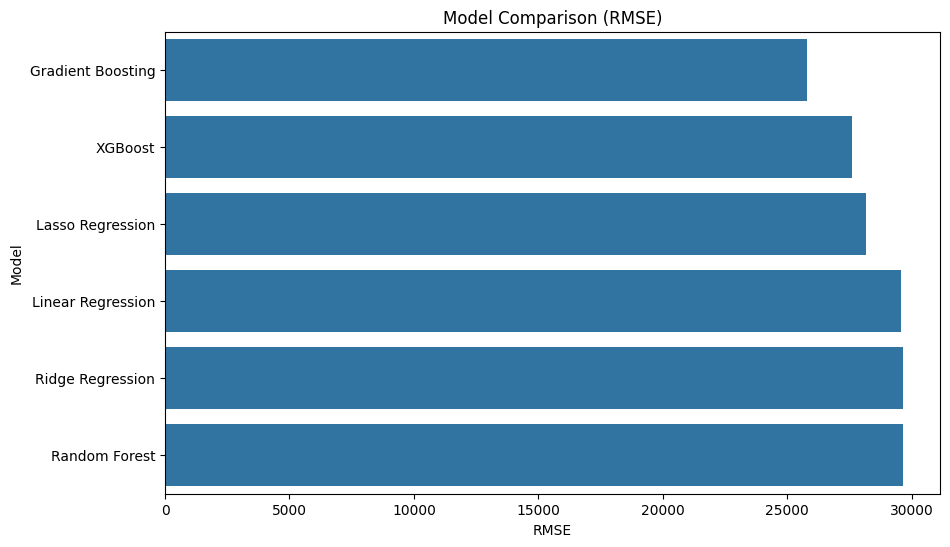

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x="RMSE",
    y="Model"
)

plt.title("Model Comparison (RMSE)")

plt.show()

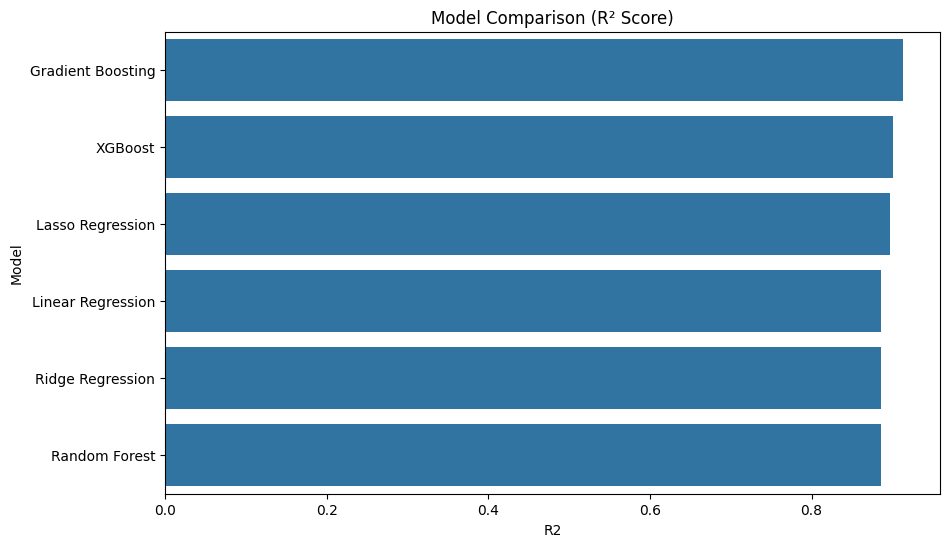

In [13]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x="R2",
    y="Model"
)

plt.title("Model Comparison (R² Score)")

plt.show()

Feature Importance

Choose the best-performing tree-based model

In [14]:
best_model = trained_models["XGBoost"]

In [15]:
importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": best_model.feature_importances_

})

In [16]:
importance = importance.sort_values(
    by="Importance",
    ascending=False
).head(20)

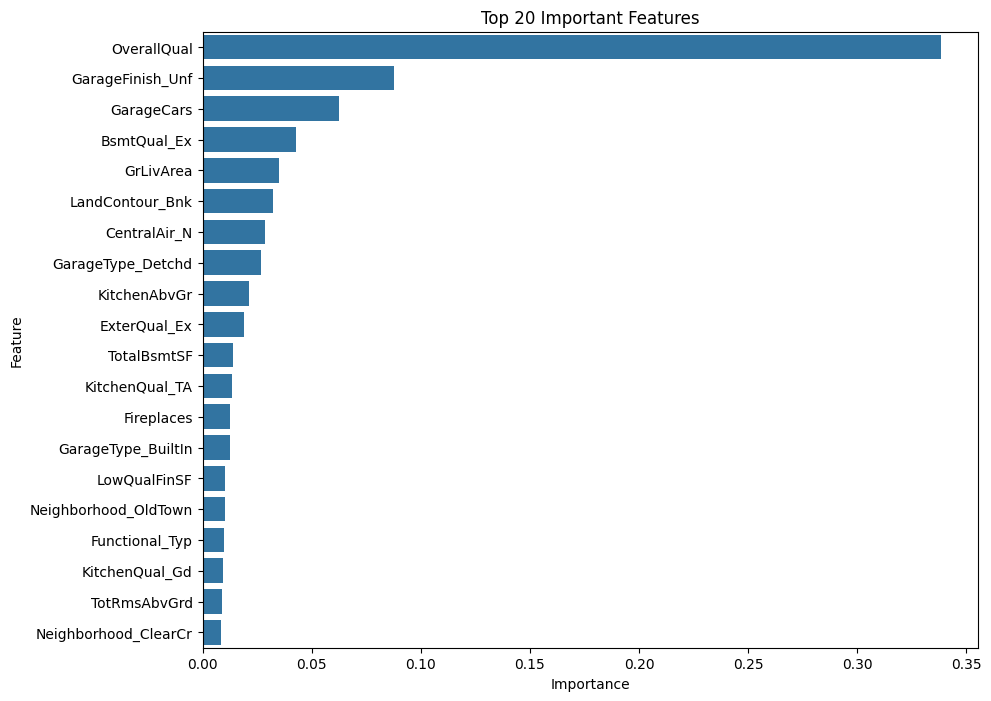

In [17]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Important Features")

plt.show()

Save Evaluation Results

In [18]:
results_df.to_csv(
    "../reports/model_results.csv",
    index=False
)

Save feature importance:

In [19]:
importance.to_csv(
    "../reports/feature_importance.csv",
    index=False
)

Save Figures

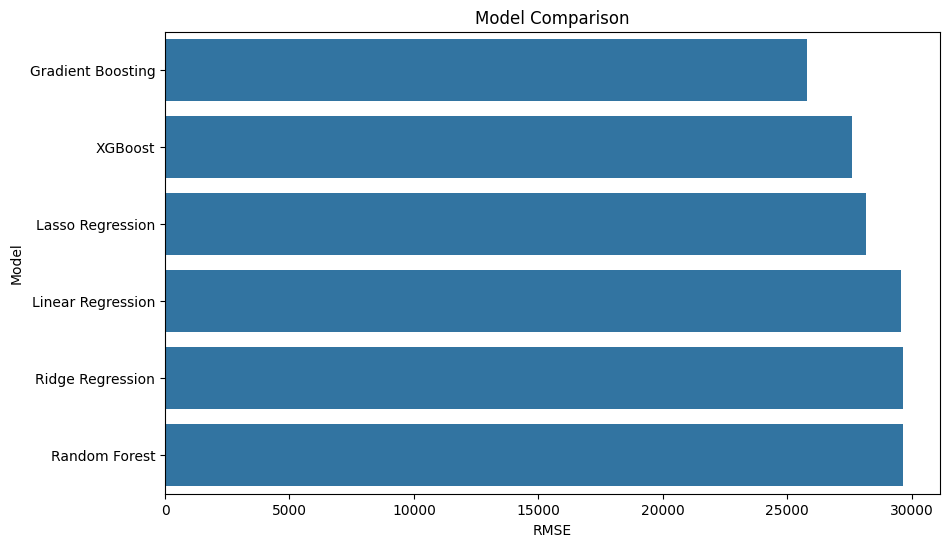

In [20]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x="RMSE",
    y="Model"
)

plt.title("Model Comparison")

plt.savefig(
    "../reports/figures/model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Markdown Conclusions

# Model Training Summary

## Models Evaluated

- Linear Regression
- Ridge Regression
- Lasso Regression
- Random Forest
- Gradient Boosting
- XGBoost

## Evaluation Metrics

- MAE
- RMSE
- R² Score

## Best Performing Model

The model with the lowest RMSE and highest R² will be selected for hyperparameter tuning in the next notebook.

## Business Insight

Tree-based ensemble methods performed better than linear models, indicating that house prices depend on complex, non-linear relationships between features.